# Проверка алгоритма сборки графа улично-одорожной сети

In [1]:
import osmnx as ox
import geopandas as gpd
import networkx as nx

ox.__version__

'2.0.1'

EPSG:4326


<Axes: >

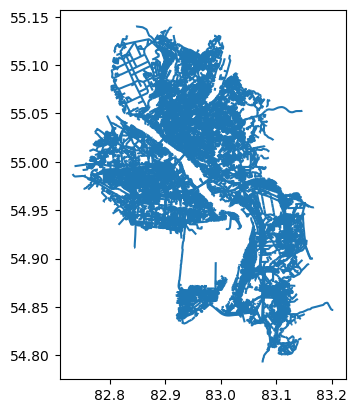

In [ ]:
# Загрузка данных о дорогах из файла .gpkg
highways = gpd.read_file('G:/QGIS/_дороги_Новосибирск/data/highways.gpkg', layer='highways')
highways.plot()

Тестирование функции сбора графа из GeoDataFrame

In [ ]:
import numpy as np
from osmnx import utils
from shapely.ops import unary_union, transform
from shapely.geometry import MultiLineString
from pyproj import Transformer


def floor_coords(geoms):
    """Округляет координаты геометрии до целых чисел в меньшую сторону"""
    def floor_coord(x, y):
        #return (math.floor(x), math.floor(y))
        return (round(x, 0), round(y, 0))
    
    return transform(floor_coord, geoms)


def graph_rise_from_gpkg(roads: gpd.GeoDataFrame,
                         oneway_field_name: str = 'oneway',
                         # lanes_field_name: str = 'lanes',  # Сейча не реализовано
                         reversed_field_name: str = 'reversed',
                         ):
    '''
    Алгоритм собирает граф дорожной сети на основе геометрии входного векторного GeoDataFrame

    Аргументы
    ---------
    `roads`: gpd.GeoDataFrame
        Датафрейм дорог
    `oneway_field_name`: str
        Поле в котором хранятся сведения о односторонности дороги
    `reversed_field_name`: str
        Поле в котором хранятся сведения о направлении движения

    Возвращает
    ----------
    `nx.MultiDiGraph`
        Граф улично-дорожной сети
    ``
    '''
    import warnings

    # Проверка наличия колонок
    #missing_cols = [col for col in [oneway_field_name, reversed_field_name] if col not in roads.columns]
    #if missing_cols:
    #    raise ValueError(f"В GeoDataFrame отсутствуют необходимые колонки: {missing_cols}")

    # Запомним исходную СК
    crs = roads.crs
    
    # Спроектируем DataFrame в местную метрическую систему координат
    try:
        roads_p = ox.projection.project_gdf(roads)
    except Exception:
        roads_p = roads

    # Округляем координаты геометрии до целых чисел
    roads_p['geometry'] = roads_p['geometry'].apply(floor_coords)

    # Создаем пустой граф
    metadata = {
            "created_date": utils.ts(),
            "created_with": f"OSMnx {ox.__version__}",
            "crs": roads_p.crs
        }
    G = nx.MultiDiGraph(**metadata)

    nodes_dict = {}
    node_id = 0

    # Словарь имеющихся ребер (для учета повторов)
    existed_edges_dict = {}

    # Перебираем все строки с записями фрагментов дорог
    for _, road in roads_p.iterrows():
        geometry = road['geometry']

        # Обработка MultiLineString
        # Это нужно проверить
        if isinstance(geometry, MultiLineString):
            lines = geometry.geoms
        else:
            lines = [geometry]

        road_data = road  #[columns_list]
        road_data = {k: v[0] if isinstance(v, list) else v for k, v in road_data.items()}
        del road_data['geometry']

        # Перебираем все линии в геометрии (может быть несколько для MultiLineString)
        for line in lines:
            coords = list(line.coords)

            # Добавляем узлы в граф
            for coord in coords:
                if coord not in nodes_dict:
                    nodes_dict[coord] = node_id
                    node_id += 1
                G.add_node(nodes_dict[coord], x=coord[0], y=coord[1])

            # Добавляем ребра в граф
            for coord1, coord2 in zip(coords[:-1], coords[1:]):
                length = ox.distance.euclidean(y1=coord1[1], x1=coord1[0],
                                              y2=coord2[1], x2=coord2[0])

                # Универсальная обработка oneway
                oneway = road_data.get(oneway_field_name, False)
                # Проверка на NaN
                if isinstance(oneway, float) and np.isnan(oneway):
                    oneway = False
                elif isinstance(oneway, str):
                    oneway = oneway.lower() in ['yes', 'true', '1']
                elif isinstance(oneway, (int, float)):
                    oneway = bool(oneway)
                road_data[oneway_field_name] = oneway

                # Универсальная обработка reversed
                reversed_val = road_data.get(reversed_field_name, False)
                if isinstance(reversed_val, float) and np.isnan(reversed_val):
                    reversed_val = False
                elif isinstance(reversed_val, str):
                    reversed_val = reversed_val.lower() in ['yes', 'true', '1']
                elif isinstance(reversed_val, (int, float)):
                    reversed_val = bool(reversed_val)
                road_data[reversed_field_name] = reversed_val

                if not oneway:
                    # Двусторонняя дорога — ребра в обе стороны
                    key = existed_edges_dict.get((nodes_dict[coord2], nodes_dict[coord1]), 0)
                    G.add_edge(nodes_dict[coord2], nodes_dict[coord1], key,
                               **road_data, length=length)
                    existed_edges_dict[(nodes_dict[coord2], nodes_dict[coord1])] = key + 1

                    key = existed_edges_dict.get((nodes_dict[coord1], nodes_dict[coord2]), 0)
                    G.add_edge(nodes_dict[coord1], nodes_dict[coord2], key,
                               **road_data, length=length)
                    existed_edges_dict[(nodes_dict[coord1], nodes_dict[coord2])] = key + 1
                else:
                    # Односторонняя дорога
                    if reversed_val:
                        # Движение в обратном направлении
                        key = existed_edges_dict.get((nodes_dict[coord2], nodes_dict[coord1]), 0)
                        G.add_edge(nodes_dict[coord2], nodes_dict[coord1], key,
                                   **road_data, length=length)
                        existed_edges_dict[(nodes_dict[coord2], nodes_dict[coord1])] = key + 1
                    else:
                        # Движение в прямом направлении
                        key = existed_edges_dict.get((nodes_dict[coord1], nodes_dict[coord2]), 0)
                        G.add_edge(nodes_dict[coord1], nodes_dict[coord2], key,
                                   **road_data, length=length)
                        existed_edges_dict[(nodes_dict[coord1], nodes_dict[coord2])] = key + 1

    # Также вызываем project_graph для перепроецирования геометрии рёбер (если она есть)
    G = ox.projection.project_graph(G, to_crs=crs)

    return G



#======================================================================================
# Проверка
print('СК highways', highways.crs)
G = graph_rise_from_gpkg(highways)


# Проверка связности
if nx.is_strongly_connected(G):
    print("✓ Граф является сильно связным")
else:
    print("⚠ Граф не является сильно связным (есть несвязанные компоненты)")
    components = list(nx.strongly_connected_components(G))
    print(f"  Количество компонент связности: {len(components)}")
    largest_component = max(components, key=len)
    print(f"  Размер наибольшей компоненты: {len(largest_component)} узлов")
    
    # Если граф не связный, можно использовать только наибольшую компоненту
    if len(components) > 1:
        print("  Рекомендация: использовать наибольшую компоненту для расчетов")

print(G.graph['crs'])
ox.graph_to_gdfs(G, nodes=False).geometry.head()

СК highways EPSG:4326
⚠ Граф не является сильно связным (есть несвязанные компоненты)
  Количество компонент связности: 90
  Размер наибольшей компоненты: 113998 узлов
  Рекомендация: использовать наибольшую компоненту для расчетов
EPSG:4326


u  v       key
0  1       0       LINESTRING (82.92755 55.03353, 82.9277 55.03355)
   6650    0      LINESTRING (82.92755 55.03353, 82.92758 55.03346)
   6651    0       LINESTRING (82.92755 55.03353, 82.92754 55.0336)
   114810  0      LINESTRING (82.92755 55.03353, 82.92741 55.03352)
1  0       0       LINESTRING (82.9277 55.03355, 82.92755 55.03353)
Name: geometry, dtype: geometry

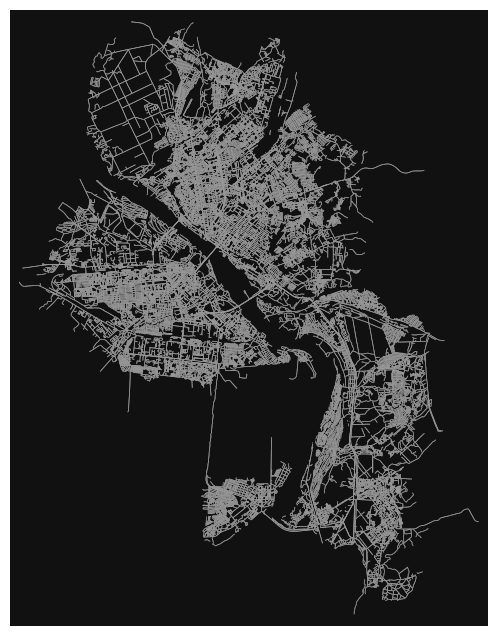

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [8]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

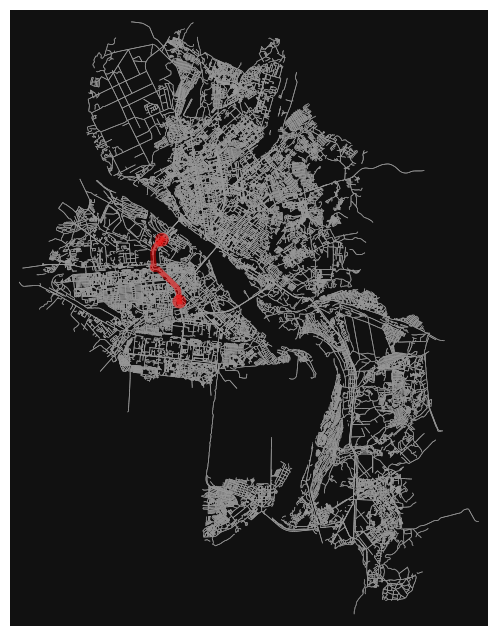

In [ ]:
route = ox.shortest_path(G, 100, 1000, weight='length')
fig, ax = ox.plot_graph_route(G, route, node_size=0, edge_linewidth=0.5)

Узел 5000
Печатаем карту


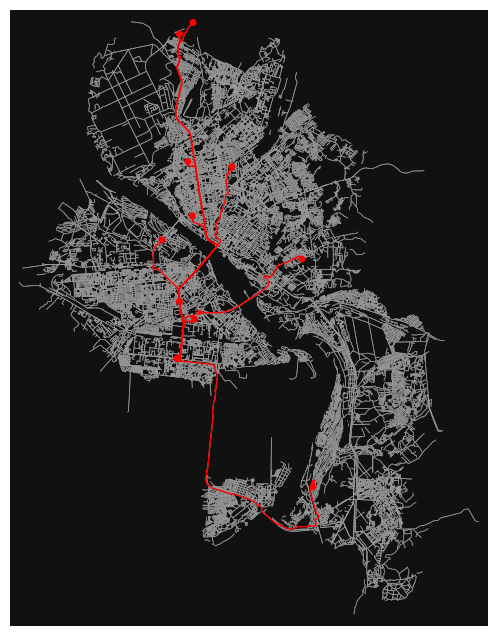

In [26]:
target_nodes = [100, 200, 500, 600, 700, 800, 1000, 2000, 3000, 4000, 5000]

routes = []

for node in target_nodes:
    print('Узел', node, end='\r')
    route = ox.shortest_path(G, 2000, node, weight='length')
    routes.append(route)
print()
print('Печатаем карту')

fig, ax = ox.plot_graph_routes(G, routes,
    node_size        = 0, 
    edge_linewidth   = 0.5,
    route_colors     = 'red',
    route_linewidths = 1,
    route_alpha      = 1,
    orig_dest_size   = 25,
    )

In [27]:
ox.graph_to_gdfs(G, nodes=False).head()

NAME      HIGHWAY OSM_TYPE    OSM_ID  oneway  \
u v      key                                                               
0 1      0    Ядринцевская улица  residential      way  25642954   False   
  6650   0       Каменская улица     tertiary      way  95212567   False   
  6651   0       Каменская улица     tertiary      way  95212567   False   
  114810 0    Ядринцевская улица  residential      way  25754453   False   
1 0      0    Ядринцевская улица  residential      way  25642954   False   

              reversed    length ONEWAY LANES  SURFACE MAXSPEED NAME_EN  \
u v      key                                                              
0 1      0       False  9.219544    NaN   NaN      NaN      NaN     NaN   
  6650   0       False  8.246211    yes     2  asphalt      NaN     NaN   
  6651   0       False  8.062258    yes     2  asphalt      NaN     NaN   
  114810 0       False  9.055385    NaN   NaN      NaN      NaN     NaN   
1 0      0       False  9.219544    NaN   NaN      NaN      NaN     NaN   

             NAME_RU  REF BRIDGE TUNNEL WIDTH  \
u v      key                                    
0 1      0       NaN  NaN    NaN    NaN   NaN   
  6650   0       NaN  NaN    NaN    NaN   NaN   
  6651   0       NaN  NaN    NaN    NaN   NaN   
  114810 0       NaN  NaN    NaN    NaN   NaN   
1 0      0       NaN  NaN    NaN    NaN   NaN   

                                                       geometry  
u v      key                                                     
0 1      0     LINESTRING (82.92755 55.03353, 82.9277 55.03355)  
  6650   0    LINESTRING (82.92755 55.03353, 82.92758 55.03346)  
  6651   0     LINESTRING (82.92755 55.03353, 82.92754 55.0336)  
  114810 0    LINESTRING (82.92755 55.03353, 82.92741 55.03352)  
1 0      0     LINESTRING (82.9277 55.03355, 82.92755 55.03353)

### Дополнительно со скоростями

In [20]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS

set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

Узел 5000
Печатаем карту


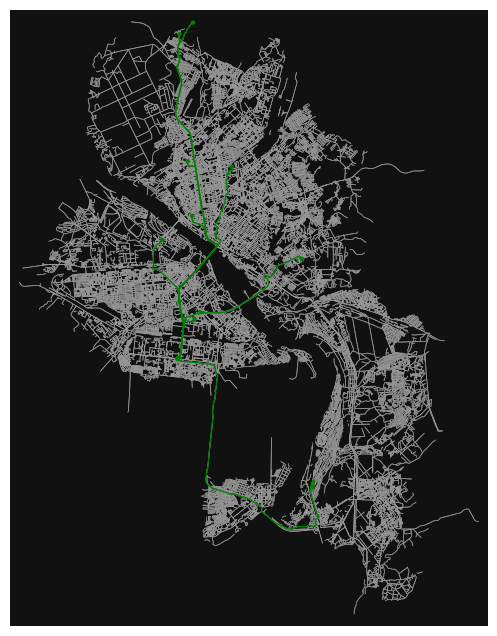

In [ ]:
target_nodes = [100, 200, 500, 600, 700, 800, 1000, 2000, 3000, 4000, 5000]

routes = []

for node in target_nodes:
    print('Узел', node, end='\r')
    route = ox.shortest_path(G, 2000, node, weight='length')
    routes.append(route)
print()
print('Печатаем карту')

fig, ax = ox.plot_graph_routes(G, routes,
    node_size        = 0, 
    edge_linewidth   = 0.5,
    route_colors     = 'green',
    route_linewidths = 1,
    route_alpha      = 1,
    orig_dest_size   = 25,
    )